# **Import Modules**

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import optuna


# **Load The Dataset**

In [ ]:
train = pd.read_csv('train.csv')

In [ ]:
test = pd.read_csv('test.csv')

# **Data Understanding**

In [ ]:
train.head()

In [ ]:
train.info()

In [ ]:
train.isnull().sum()

In [ ]:
train.duplicated().sum()

In [ ]:
train.shape

# **EDA**

In [ ]:
# Heatmap

plt.figure(figsize=(10, 6))
sns.heatmap(train.corr(), annot= True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

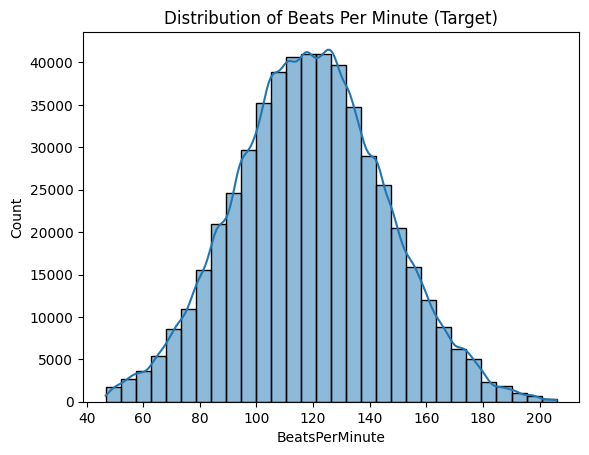

In [10]:
# Quick distribution

sns.histplot(train["BeatsPerMinute"], kde=True, bins=30)
plt.title("Distribution of Beats Per Minute (Target)")
plt.show()

# **Data Preprocessing**

In [11]:
X = train.drop(columns=['id', 'BeatsPerMinute'])
y = train['BeatsPerMinute']

X_test_final = test.drop(columns=['id'])

In [12]:
num_columns = X.columns.tolist()

In [13]:
# Pipeline

numeric_pipe = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, num_columns)
    ]
)

In [14]:
# Train-Test Split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# RMSE scorer for sklearn
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)  # minimize RMSE

In [16]:
def objective(trial):
    model = RandomForestRegressor(
        n_estimators=trial.suggest_int("rf_n_estimators", 50, 300),
        max_depth=trial.suggest_int("rf_max_depth", 3, 20),
        min_samples_split=trial.suggest_int("rf_min_samples_split", 2, 10),
        # min_samples_leaf=trial.suggest_int("rf_min_samples_leaf", 1, 10),
        # bootstrap=trial.suggest_categorical("rf_bootstrap", [True, False]),
        random_state=42
    )

    # Use pipeline with preprocessing
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Cross-validation with RMSE
    scores = cross_val_score(
        pipe, X_train, y_train, cv=3, scoring=rmse_scorer
    )
    return scores.mean()  # Optuna will minimize this


In [20]:
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 300, step=50)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
    num_leaves = trial.suggest_int("num_leaves", 20, 80)

    model = LGBMRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        random_state=42
    )

    # Use pipeline with preprocessing
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Cross-validation with RMSE
    scores = cross_val_score(
        pipe, X_train, y_train, cv=3, scoring=rmse_scorer
    )
    return scores.mean()  # Optuna minimizes this


In [34]:
def objective(trial):
    # Hyperparameters to try
    fit_intercept = trial.suggest_categorical("fit_intercept", [True, False])
    positive = trial.suggest_categorical("positive", [True, False])

    # Model
    model = LinearRegression(
        fit_intercept=fit_intercept,
        positive=positive
    )

    # Use pipeline with preprocessing
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Cross-validation with RMSE
    scores = cross_val_score(
        pipe, X_train, y_train, cv=3, scoring=rmse_scorer
    )
    return scores.mean()  # Optuna will minimize this


In [38]:
def objective(trial):
    # Hyperparameter suggestions
    learning_rate = trial.suggest_float("xgb_learning_rate", 0.01, 0.3, log=True)
    max_depth = trial.suggest_int("xgb_max_depth", 2, 12)
    n_estimators = trial.suggest_int("xgb_n_estimators", 50, 500)

    # Model with suggested params
    model = XGBRegressor(
        learning_rate=learning_rate,
        max_depth=max_depth,
        n_estimators=n_estimators,
        random_state=42,
        n_jobs=-1
    )

    # Use pipeline with preprocessing
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Cross-validation with RMSE
    scores = cross_val_score(
        pipe, X_train, y_train, cv=3, scoring=rmse_scorer
    )
    return scores.mean()  # Optuna will minimize this

In [39]:
study = optuna.create_study(direction="minimize")  # minimize RMSE
study.optimize(objective, n_trials=30)

[I 2025-09-14 07:50:53,528] A new study created in memory with name: no-name-a36a52b7-0468-49b7-bfc7-cec4931f73ff
[I 2025-09-14 07:51:06,662] Trial 0 finished with value: -26.574593015942906 and parameters: {'xgb_learning_rate': 0.22246749954081263, 'xgb_max_depth': 5, 'xgb_n_estimators': 213}. Best is trial 0 with value: -26.574593015942906.
[I 2025-09-14 07:51:31,798] Trial 1 finished with value: -26.476440870365945 and parameters: {'xgb_learning_rate': 0.026114739450896075, 'xgb_max_depth': 5, 'xgb_n_estimators': 380}. Best is trial 0 with value: -26.574593015942906.
[I 2025-09-14 07:51:40,385] Trial 2 finished with value: -26.468296477550794 and parameters: {'xgb_learning_rate': 0.013908501820468268, 'xgb_max_depth': 7, 'xgb_n_estimators': 63}. Best is trial 0 with value: -26.574593015942906.
[I 2025-09-14 07:52:45,963] Trial 3 finished with value: -26.518057421869145 and parameters: {'xgb_learning_rate': 0.017435687026855627, 'xgb_max_depth': 9, 'xgb_n_estimators': 383}. Best is t

In [36]:
study.best_params

{'fit_intercept': False, 'positive': True}

In [37]:
study.best_value

-121.96406690217373

In [28]:
best_model_name = "LightGBM"
best_params = study.best_params.copy()


In [29]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(**best_params, random_state=42))
])


In [30]:
best_model.fit(X, y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043756 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 524164, number of used features: 9
[LightGBM] [Info] Start training from score 119.034899


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['RhythmScore',
                                                   'AudioLoudness',
                                                   'VocalContent',
                                                   'AcousticQuality',
                                                   'InstrumentalScore',
                                                   'LivePerformanceLikelihood',
                                                   'MoodScore',
                                                   'TrackDurationMs',
                                                   'Energy'])])),
                ('model',
                 LGBMRegressor(learning_rate=0.29721549781699924,
                               n_estimators=300, num_leaves=75,
                               random_state=42))])

In [32]:
preds = best_model.predict(X_test_final)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [33]:
submission = pd.DataFrame({
    "id": test["id"],
    "BeatsPerMinute": preds
})
submission.to_csv("submission.csv", index=False)
print("✅ submission.csv saved with Optuna-tuned model!")

✅ submission.csv saved with Optuna-tuned model!
